In [1]:
import pickle

with open("dataset/resplan_numeric_100.pkl", "rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edge_index = data["edge_index"]
edge_attr = data["edge_attr"]
text = data["text"]

print(len(nodes))
print(nodes[0].shape)
print(edge_attr[0].shape)

100
(8, 11)
(10, 10)


In [2]:
from dataset.resplan_utils import plot_plan

# load numeric subset
with open("dataset/resplan_numeric_100.pkl","rb") as f:
    data = pickle.load(f)

nodes = data["nodes"]
edges = data["edge_index"]
plan_idx = data["plan_idx"]


In [4]:
import torch
import torch.nn as nn
from torch_geometric.nn import GINEConv


class RoughLayoutGNN(nn.Module):
    def __init__(self, node_dim=11, edge_dim=10, hidden=128):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, out_dim)
            )

        self.conv1 = GINEConv(mlp(node_dim, hidden), edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
        self.conv3 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 4)   # cx,cy,w,h
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = self.conv1(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = torch.relu(x)

        out = self.head(x)
        return out

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RoughLayoutGNN(node_dim=11, edge_dim=10, hidden=128).to(device)
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

RoughLayoutGNN(
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [6]:
import torch
from torch_geometric.data import Data

def build_dataset(nodes, edge_index, edge_attr):
    dataset = []

    for i in range(len(nodes)):
        x = torch.tensor(nodes[i], dtype=torch.float32)
        ei = torch.tensor(edge_index[i], dtype=torch.long)
        ea = torch.tensor(edge_attr[i], dtype=torch.float32)

        # target = cx,cy,w,h
        y = x[:, 7:11]   # adjust if ordering differs

        data = Data(
            x=x,
            edge_index=ei,
            edge_attr=ea,
            y=y
        )
        dataset.append(data)

    return dataset

In [7]:
dataset = build_dataset(nodes, edge_index, edge_attr)

train_dataset = dataset[:80]
test_dataset  = dataset[80:]

In [8]:
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_prediction(sample_idx=0):
    data = test_dataset[sample_idx].to(device)
    pred = model(data).cpu().numpy()
    gt   = data.y.cpu().numpy()

    fig, ax = plt.subplots(figsize=(5,5))

    for box, color in [(gt,"green"), (pred,"red")]:
        for cx,cy,w,h in box:
            x0 = cx - w/2
            y0 = cy - h/2
            rect = plt.Rectangle(
                (x0,y0), w, h,
                fill=False,
                edgecolor=color,
                linewidth=2
            )
            ax.add_patch(rect)

    # auto-fit canvas to include all GT and predicted boxes
    xmin = min((b[:, 0] - b[:, 2] / 2).min() for b in (gt, pred))
    xmax = max((b[:, 0] + b[:, 2] / 2).max() for b in (gt, pred))
    ymin = min((b[:, 1] - b[:, 3] / 2).min() for b in (gt, pred))
    ymax = max((b[:, 1] + b[:, 3] / 2).max() for b in (gt, pred))

    mx = 0.05 * (xmax - xmin + 1e-6)
    my = 0.05 * (ymax - ymin + 1e-6)

    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    ax.set_aspect("equal")
    plt.show()

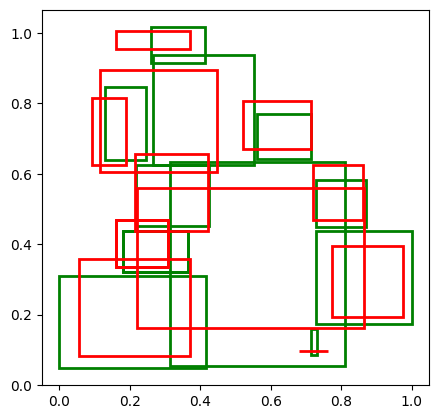

In [9]:
visualize_prediction(1)

In [10]:
def graph_layout_to_rgb(boxes, room_types, edge_index, size=512):
    import numpy as np, cv2

    N = len(boxes)

    room = np.zeros((size,size), np.float32)
    adj  = np.zeros((size,size), np.float32)
    typ  = np.zeros((size,size), np.float32)

    tmax = max(room_types) if len(room_types)>0 else 1
    centers = []

    for i,(cx,cy,w,h) in enumerate(boxes):
        x0 = int((cx-w/2)*size)
        y0 = int((cy-h/2)*size)
        x1 = int((cx+w/2)*size)
        y1 = int((cy+h/2)*size)

        x0,y0 = np.clip([x0,y0],0,size-1)
        x1,y1 = np.clip([x1,y1],0,size-1)

        inst_val = (i+1)/(N+1)

        mask = np.zeros((size,size), np.float32)
        mask[y0:y1,x0:x1] = 1.0

        room = np.maximum(room, mask*inst_val)
        typ  = np.maximum(typ,  mask*(room_types[i]/(tmax+1e-6)))

        cv2.rectangle(room,(x0,y0),(x1,y1),1.0,2)

        centers.append((int(cx*size), int(cy*size)))

    for k in range(edge_index.shape[1]):
        i,j = edge_index[:,k]
        cv2.line(adj, centers[i], centers[j], 1.0, 2)

    rgb = np.stack([room, adj, typ], axis=2)
    rgb = (rgb*255).astype(np.uint8)
    return rgb

In [11]:
model.eval()

data = test_dataset[11].to(device)

with torch.no_grad():
    pred = model(data)

boxes = pred.cpu().numpy()

# normalize boxes
xmin = (boxes[:,0] - boxes[:,2]/2).min()
ymin = (boxes[:,1] - boxes[:,3]/2).min()
xmax = (boxes[:,0] + boxes[:,2]/2).max()
ymax = (boxes[:,1] + boxes[:,3]/2).max()

boxes_norm = boxes.copy()
boxes_norm[:,0] = (boxes[:,0] - xmin) / (xmax - xmin + 1e-6)
boxes_norm[:,1] = (boxes[:,1] - ymin) / (ymax - ymin + 1e-6)
boxes_norm[:,2] = boxes[:,2] / (xmax - xmin + 1e-6)
boxes_norm[:,3] = boxes[:,3] / (ymax - ymin + 1e-6)

# extract types from one-hot
num_semantic = 7
room_types = data.x[:, :num_semantic].argmax(1).cpu().numpy()

edges = data.edge_index.cpu().numpy()

# ⭐ regenerate control image
control_img = graph_layout_to_rgb(boxes_norm, room_types, edges)

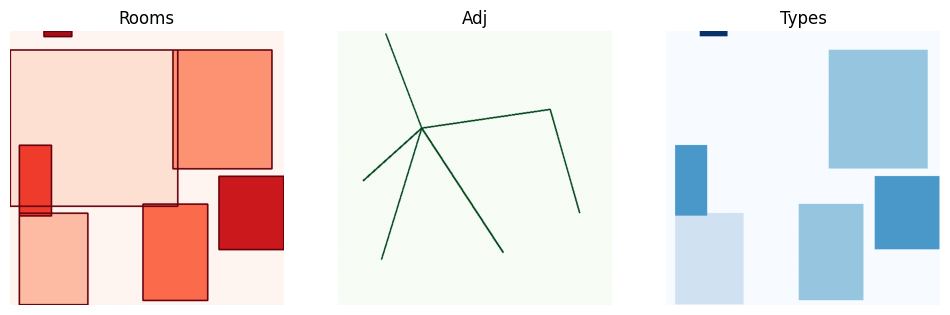

In [20]:
fig,ax = plt.subplots(1,3,figsize=(12,4))
ax[0].imshow(control_img[:,:,0], cmap="Reds"); ax[0].set_title("Rooms")
ax[1].imshow(control_img[:,:,1], cmap="Greens"); ax[1].set_title("Adj")
ax[2].imshow(control_img[:,:,2], cmap="Blues"); ax[2].set_title("Types")
for a in ax: a.axis("off")

In [21]:
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline
import torch

device = "cuda"

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11p_sd15_seg",
    torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to(device)


/home/dexter/floorplan/FloorPlan-Pipeline/venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading weights: 100%|██████████| 396/396 [00:00<00:00, 1048.55it/s, Materializing param=visual_projection.weight]
StableDiffusionSafetyChecker LOAD REPORT from: /home/dexter/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1274.90it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /home/dexter/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------

In [22]:
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to(device)


Loading weights: 100%|██████████| 396/396 [00:00<00:00, 1075.52it/s, Materializing param=visual_projection.weight]
StableDiffusionSafetyChecker LOAD REPORT from: /home/dexter/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1346.64it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: /home/dexter/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------

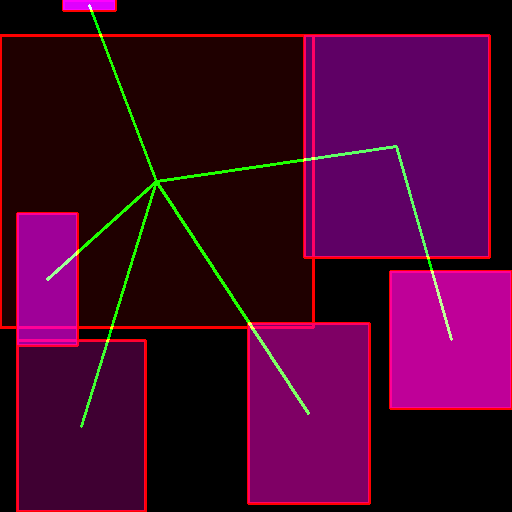

In [23]:
from PIL import Image

control_pil = Image.fromarray(control_img)
control_pil

  0%|          | 0/40 [00:00<?, ?it/s]

100%|██████████| 40/40 [00:03<00:00, 11.53it/s]


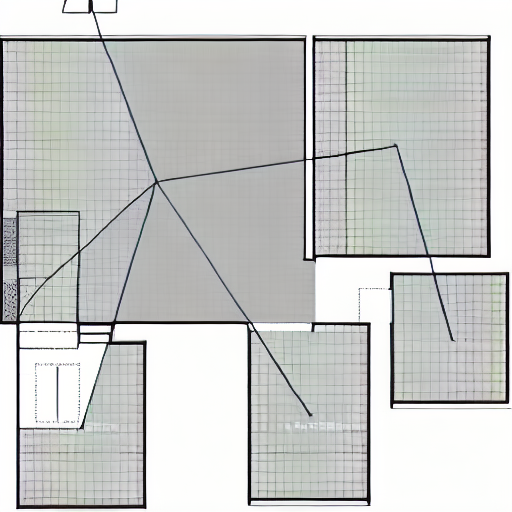

In [24]:
prompt = (
    "clean architectural floor plan, thin black walls, white background, "
    "rooms separated by walls, door openings between adjacent rooms, "
    "2d blueprint, line drawing"
)

negative = (
    "wood, floor texture, shading, material, roof, tiles, 3d, perspective"
)
result = pipe(
    prompt=prompt,
    negative_prompt=negative,
    image=control_pil,
    num_inference_steps=40,
    guidance_scale=8.0,
    controlnet_conditioning_scale=1.6
).images[0]
result

In [25]:
from diffusers import ControlNetModel

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11p_sd15_canny",
    torch_dtype=torch.float16
)

/home/dexter/floorplan/FloorPlan-Pipeline/venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [26]:
import cv2

control_gray = cv2.cvtColor(control_img, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(control_gray, 50, 150)

from PIL import Image
control_pil = Image.fromarray(edges)

100%|██████████| 40/40 [00:03<00:00, 11.51it/s]


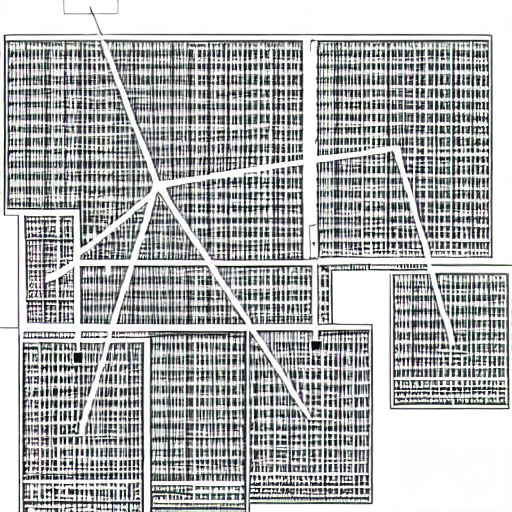

In [27]:
prompt = (
    "architectural floor plan, thin black walls, white background, "
    "technical blueprint, 2d line drawing"
)

negative = (
    "texture, shading, material, floor, roof, 3d, perspective"
)

result = pipe(
    prompt=prompt,
    negative_prompt=negative,
    image=control_pil,
    num_inference_steps=40,
    guidance_scale=8.0,
    controlnet_conditioning_scale=1.4
).images[0]

result

In [28]:
import numpy as np

def boxes_to_polygons(boxes):
    """
    boxes: [N,4] cx,cy,w,h
    returns: [N,4,2] polygon corners (clockwise)
    """
    polys = []

    for cx,cy,w,h in boxes:
        x0 = cx - w/2
        x1 = cx + w/2
        y0 = cy - h/2
        y1 = cy + h/2

        poly = np.array([
            [x0,y0],
            [x1,y0],
            [x1,y1],
            [x0,y1]
        ], dtype=np.float32)

        polys.append(poly)

    return np.stack(polys)

In [30]:
def flatten_polys(polys):
    # [N,4,2] → [N,8]
    return polys.reshape(len(polys), -1)

In [31]:
import torch
import torch.nn as nn
from torch_geometric.nn import GINEConv

class PolygonRefineGNN(nn.Module):
    def __init__(self, node_dim=8+7, edge_dim=10, hidden=128):
        super().__init__()

        def mlp(in_dim,out_dim):
            return nn.Sequential(
                nn.Linear(in_dim,hidden),
                nn.ReLU(),
                nn.Linear(hidden,out_dim)
            )

        self.conv1 = GINEConv(mlp(node_dim,hidden), edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp(hidden,hidden), edge_dim=edge_dim)
        self.conv3 = GINEConv(mlp(hidden,hidden), edge_dim=edge_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden,hidden),
            nn.ReLU(),
            nn.Linear(hidden,8)   # refined corners
        )

    def forward(self,data):
        x,ei,ea = data.x, data.edge_index, data.edge_attr

        x = torch.relu(self.conv1(x,ei,ea))
        x = torch.relu(self.conv2(x,ei,ea))
        x = torch.relu(self.conv3(x,ei,ea))

        return self.head(x)

In [32]:
from torch_geometric.data import Data

def build_refine_dataset(nodes, edge_index, edge_attr):
    dataset = []

    for i in range(len(nodes)):
        full = nodes[i]

        gt_boxes = full[:,7:11]
        types    = full[:,:7]

        gt_polys = boxes_to_polygons(gt_boxes)
        gt_flat  = flatten_polys(gt_polys)

        # rough = jitter GT (simulate rough GNN)
        noise = np.random.normal(0,0.05,gt_boxes.shape)
        rough_boxes = gt_boxes + noise

        rough_polys = boxes_to_polygons(rough_boxes)
        rough_flat  = flatten_polys(rough_polys)

        x = np.concatenate([rough_flat, types], axis=1)

        data = Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=torch.tensor(edge_index[i], dtype=torch.long),
            edge_attr=torch.tensor(edge_attr[i], dtype=torch.float32),
            y=torch.tensor(gt_flat, dtype=torch.float32)
        )

        dataset.append(data)

    return dataset

In [33]:
def refine_loss(pred, target):
    return torch.nn.functional.l1_loss(pred,target)

In [34]:
def train_epoch():
    model.train()
    total=0
    for data in loader:
        data=data.to(device)

        optimizer.zero_grad()
        pred=model(data)
        loss=refine_loss(pred,data.y)
        loss.backward()
        optimizer.step()

        total+=loss.item()
    return total/len(loader)

In [35]:
rough_boxes = pred_boxes
rough_polys = boxes_to_polygons(rough_boxes)
rough_flat  = flatten_polys(rough_polys)

x = np.concatenate([rough_flat, room_types], axis=1)

data = Data(
    x=torch.tensor(x).float(),
    edge_index=edge_index,
    edge_attr=edge_attr
).to(device)

refined_flat = refine_model(data).cpu().numpy()
refined_polys = refined_flat.reshape(-1,4,2)

NameError: name 'pred_boxes' is not defined